In [11]:
import pandas as pd
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
import warnings
import IPython
from IPython.display import display, Markdown
import sys

print(f"python=={sys.version.split()[0]}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"networkx=={nx.__version__}")
print(f"mlxtend=={mlxtend.__version__}")
print(f"ipython=={IPython.__version__}")

# --- Setup & Optimization ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mlxtend')
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def optimize_types(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

# --- Data Loading & Preprocessing ---
def load_and_prep_data():
    products = pd.read_csv('products.csv')
    aisles = pd.read_csv('aisles.csv')
    departments = pd.read_csv('departments.csv')
    order_products = pd.read_csv('order_products__prior.csv', nrows = 2e5)
    orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]

    # Merging
    df = order_products.merge(products, on='product_id', how='left')
    df = df.merge(aisles, on='aisle_id', how='left')
    df = df.merge(departments, on='department_id', how='left')
    df = df.merge(orders, on='order_id', how='left')

    # Dimensional Engineering
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = 'Hour_' + pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False).astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    
    return optimize_types(df)

# --- Exploratory Data Analysis ---
def run_eda(df):
    display(Markdown("## Exploratory Data Analysis"))
    
    # 1. Missing Values Check
    display(Markdown("--- Missing Values Check ---"))
    missing_data = df[['product_name', 'aisle', 'department', 'order_hour_of_day', 'order_dow']].isna().sum()
    display(missing_data.to_frame(name='Missing Count'))
    display(Markdown(f"- **Total transactions (orders):** `{df['order_id'].nunique():,}`\n- **Total unique products:** `{df['product_name'].nunique():,}`"))
    plt.figure(figsize=(16, 10))
    
    # Orders by Day of Week
    plt.subplot(2, 2, 1)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_dow')
    plt.title('Distribution of Orders by Day of Week')
    plt.xlabel('Day of Week (0=Saturday)')
    plt.ylabel('Number of Orders')
    
    # Orders by Hour of Day
    plt.subplot(2, 2, 2)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_hour_of_day')
    plt.title('Distribution of Orders by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Orders')
    
    # Top 10 Departments
    plt.subplot(2, 2, 3)
    top_depts = df['department'].value_counts().head(10)
    sns.barplot(y=top_depts.index, x=top_depts.values)
    plt.title('Top 10 Most Frequent Departments')
    plt.xlabel('Frequency')
    plt.ylabel('Department')
    
    # Top 10 Aisles
    plt.subplot(2, 2, 4)
    top_aisles = df['aisle'].value_counts().head(10)
    sns.barplot(y=top_aisles.index, x=top_aisles.values)
    plt.title('Top 10 Most Frequent Aisles')
    plt.xlabel('Frequency')
    plt.ylabel('Aisle')
    
    plt.tight_layout()
    plt.show()


# --- Core Mining Utilities ---
def get_basket(df, level_column):
    """Prepares sparse TransactionEncoder dataframe."""
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    
    transaction_list = [list(items) + list(meta) for items, meta in zip(merged[level_column], merged[['hour_bin', 'day_type', 'basket_size']].values)]
    
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

def enhance_rules(rules_df, level_type):
    """Calculates Kulc/IR/Cosine and applies level-specific thresholds."""
    if rules_df.empty: return rules_df
    
    rules_df['kulczynski'] = (rules_df['support']/rules_df['antecedent support'] + 
                              rules_df['support']/rules_df['consequent support']) / 2
    
    rules_df['ir'] = np.abs(rules_df['antecedent support'] - rules_df['consequent support']) / \
                     (rules_df['antecedent support'] + rules_df['consequent support'] - rules_df['support'])
    
    rules_df['cosine'] = rules_df['support'] / np.sqrt(rules_df['antecedent support'] * rules_df['consequent support'])
    
    if level_type == 'product_name':
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.3) & (rules_df['ir'] < 0.7)
    else: 
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.5) & (rules_df['ir'] < 0.5)
    
    rules_df['ant_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['cons_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    return rules_df

def filter_redundancy(low_rules, high_rules, mapping):
    if low_rules.empty or high_rules is None or high_rules.empty or mapping is None: return low_rules
    
    high_set = set((tuple(sorted(list(a))), tuple(sorted(list(c)))) for a, c in zip(high_rules['antecedents'], high_rules['consequents']))

    def check_redundancy(row):
        ant_high = tuple(sorted(set(mapping.get(item, item) for item in row['antecedents'])))
        cons_high = tuple(sorted(set(mapping.get(item, item) for item in row['consequents'])))
        return (ant_high, cons_high) in high_set

    return low_rules[~low_rules.apply(check_redundancy, axis=1)]

# --- Visualization ---
def plot_robustness(rules_df, title):
    if rules_df.empty: return
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=rules_df, x='kulczynski', y='ir', size='lift', hue='is_robust', palette={True: 'green', False: 'red'}, alpha=0.6)
    plt.title(f"Robustness: {title}")
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.show()

def plot_rules_network(rules_df, title="Association Rules Network", num_rules=50):
    if rules_df.empty: return
    G = nx.DiGraph()
    top_rules = rules_df[rules_df['is_robust']].sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows(): G.add_edge(row['ant_str'], row['cons_str'], weight=row['lift'])

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=1.1, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="#ecf0f1", edgecolors='#2C3E50', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')
    
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    normalized_weights = [(w / max_w) * 5 for w in weights]
    
    nx.draw_networkx_edges(G, pos, width=normalized_weights, edge_color='#3498DB', alpha=0.6, arrowsize=20, connectionstyle='arc3,rad=0.1')

    plt.title(f"{title}\n(Line thickness = Lift)", fontsize=14)
    plt.axis('off')
    plt.show()   
    
def plot_dimensional_heatmap(rules_df, title="Dimensional Heatmap"):
    if rules_df.empty or len(rules_df) < 2: return
    heatmap_data = rules_df.pivot_table(index='ant_str', columns='cons_str', values='lift', aggfunc='max')
    
    if heatmap_data.shape[0] > 15: heatmap_data = heatmap_data.head(15)
    if heatmap_data.shape[1] > 15: heatmap_data = heatmap_data.iloc[:, :15]
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Lift'})
    plt.title(f"Rule Lift Heatmap: {title}")
    plt.ylabel("Antecedents")
    plt.xlabel("Consequents")
    plt.tight_layout()
    plt.show()

def plot_algorithm_comparison(performance_log):
    if not performance_log: return
    perf_df = pd.DataFrame(performance_log)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=perf_df.melt(id_vars=['Level', 'Dimension'], value_vars=['Apriori', 'FP-Growth'], 
                                  var_name='Algorithm', value_name='Time (s)'), 
                x='Level', y='Time (s)', hue='Algorithm')
    plt.title('Scalability Comparison: Apriori vs. FP-Growth')
    plt.yscale('log')
    plt.ylabel('Execution Time in Seconds (Log Scale)')
    plt.xlabel('Hierarchy Level')
    plt.show()

# --- Master Pipeline ---
def run_master_analysis(df):
    run_eda(df)
    mapping_data = df[['product_name', 'aisle', 'department']].drop_duplicates()
    prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
    aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()

    level_configs = [
        ('department', 0.1, None),
        ('aisle', 0.02, aisle_to_dept),
        ('product_name', 0.005, prod_to_aisle)
    ]
    
    results = {}
    performance_log = []

    for dim in ['Weekend', 'Weekday']:
        display(Markdown(f"<br>\n\n---\n## DIMENSION: **{dim.upper()}**\n---"))
        
        df_subset = df[df['day_type'] == dim]
        prev_rules = None
        
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            
            apriori_time = None
            start_apri = time.time()
            _ = apriori(basket_df, min_support=sup, use_colnames=True)
            apriori_time = time.time() - start_apri
            start_fp = time.time()
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            fp_time = time.time() - start_fp
            rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            display(Markdown(f"### LEVEL: **{level.upper()}** *(Min Support: {sup})*"))
            display(Markdown(f"- **Rules Found:** `{len(rules):,}`\n- **Unique Rules:** `{len(filtered_rules):,}`\n- **Robust Rules:** `{robust_count:,}`"))
            
            if apriori_time:
                display(Markdown(f"**Performance:** Apriori took `{apriori_time:.2f}s` | FP-Growth took `{fp_time:.2f}s` *(⚡ FP-Growth is **{apriori_time/fp_time:.1f}x** faster)*"))
            else:
                display(Markdown(f"**Performance:** FP-Growth took `{fp_time:.2f}s`"))
            
            if robust_count > 0:
                robust_rules = filtered_rules[filtered_rules['is_robust']]
                plot_dimensional_heatmap(robust_rules, title=f"{dim} - {level}")
            
            results[(dim, level)] = filtered_rules
            prev_rules = rules
            print("-" * 40)
    
    ####      
    for dim in ['Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']:
        display(Markdown(f"<br>\n\n---\n## DIMENSION: **{dim.upper()}**\n---"))
        
        df_subset = df[df['hour_bin'] == dim]
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            
            apriori_time = None
            start_apri = time.time()
            _ = apriori(basket_df, min_support=sup, use_colnames=True)
            apriori_time = time.time() - start_apri
            start_fp = time.time()
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            fp_time = time.time() - start_fp
            rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            display(Markdown(f"### LEVEL: **{level.upper()}** *(Min Support: {sup})*"))
            display(Markdown(f"- **Rules Found:** `{len(rules):,}`\n- **Unique Rules:** `{len(filtered_rules):,}`\n- **Robust Rules:** `{robust_count:,}`"))
            
            if apriori_time:
                display(Markdown(f"**Performance:** Apriori took `{apriori_time:.2f}s` | FP-Growth took `{fp_time:.2f}s` *(⚡ FP-Growth is **{apriori_time/fp_time:.1f}x** faster)*"))
            else:
                display(Markdown(f"**Performance:** FP-Growth took `{fp_time:.2f}s`"))
            
            if robust_count > 0:
                robust_rules = filtered_rules[filtered_rules['is_robust']]
                plot_dimensional_heatmap(robust_rules, title=f"{dim} - {level}")
            
            results[(dim, level)] = filtered_rules
            prev_rules = rules  
    
    display(Markdown("## Algorithm Performance Comparison"))
    plot_algorithm_comparison(performance_log)
    return results

python==3.11.9
pandas==3.0.1
numpy==2.4.3
matplotlib==3.10.8
seaborn==0.13.2
networkx==3.4.2
mlxtend==0.24.0
ipython==9.3.0


## main code

## Exploratory Data Analysis

--- Missing Values Check ---

,Missing Count
product_name,0
aisle,0
department,0
order_hour_of_day,0
order_dow,0


- **Total transactions (orders):** `19,850`
- **Total unique products:** `21,494`

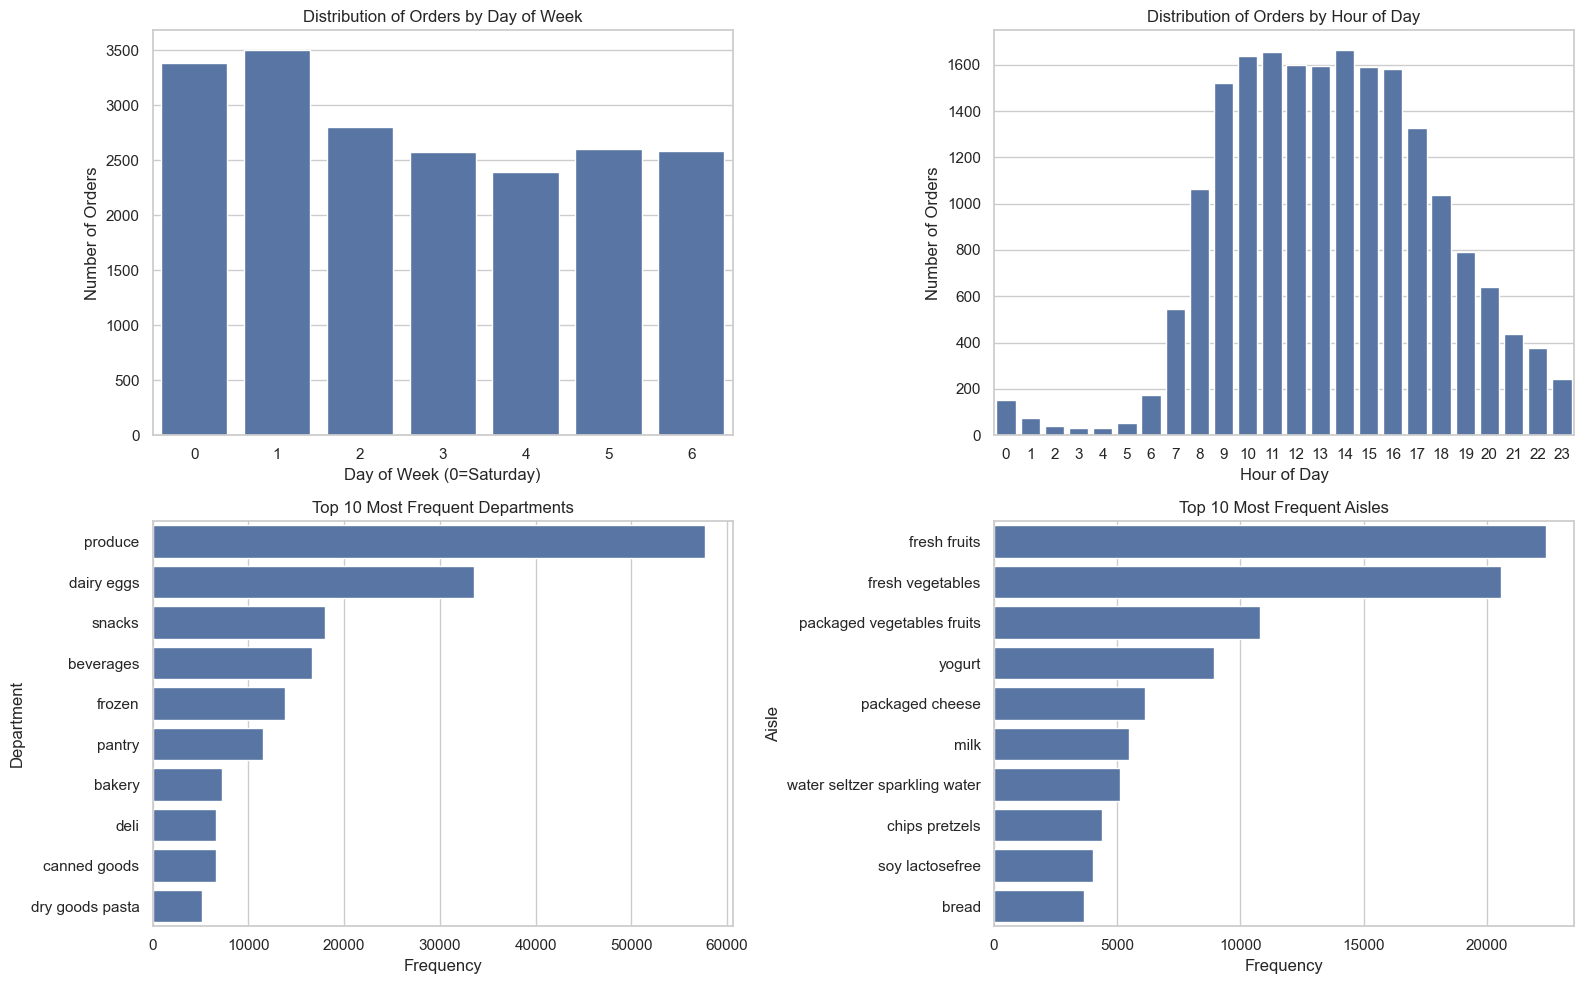

<br>

---
## DIMENSION: **WEEKEND**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `3,714`
- **Unique Rules:** `3,714`
- **Robust Rules:** `272`

**Performance:** Apriori took `0.12s` | FP-Growth took `0.09s` *(⚡ FP-Growth is **1.4x** faster)*

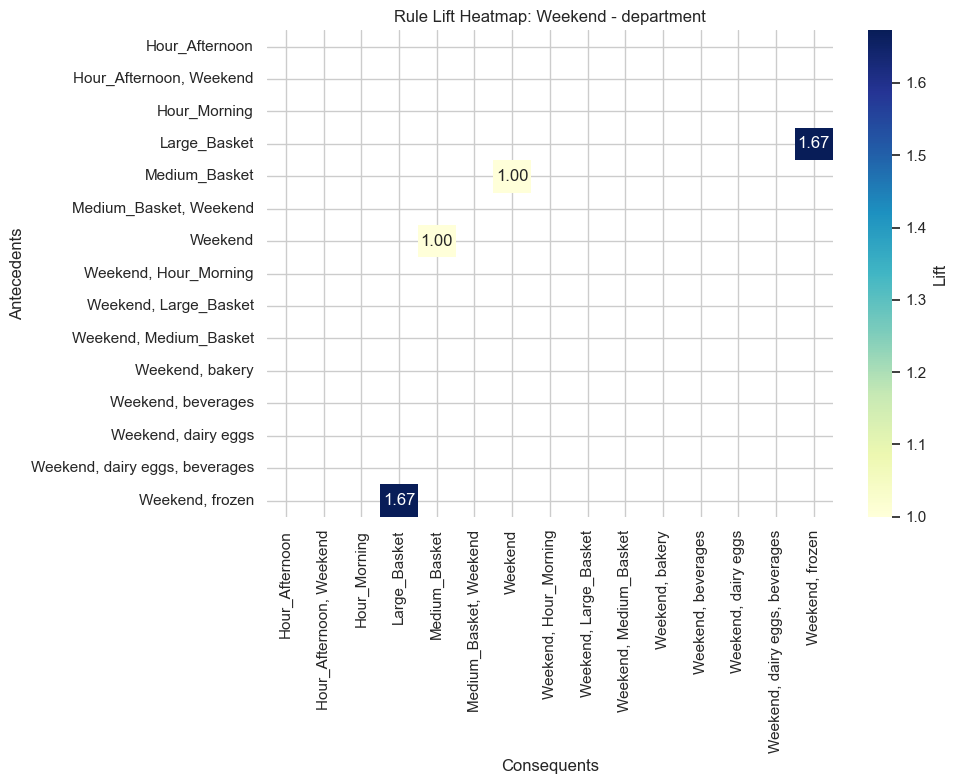

----------------------------------------


### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `65,718`
- **Unique Rules:** `40,058`
- **Robust Rules:** `60`

**Performance:** Apriori took `6.47s` | FP-Growth took `0.41s` *(⚡ FP-Growth is **15.6x** faster)*

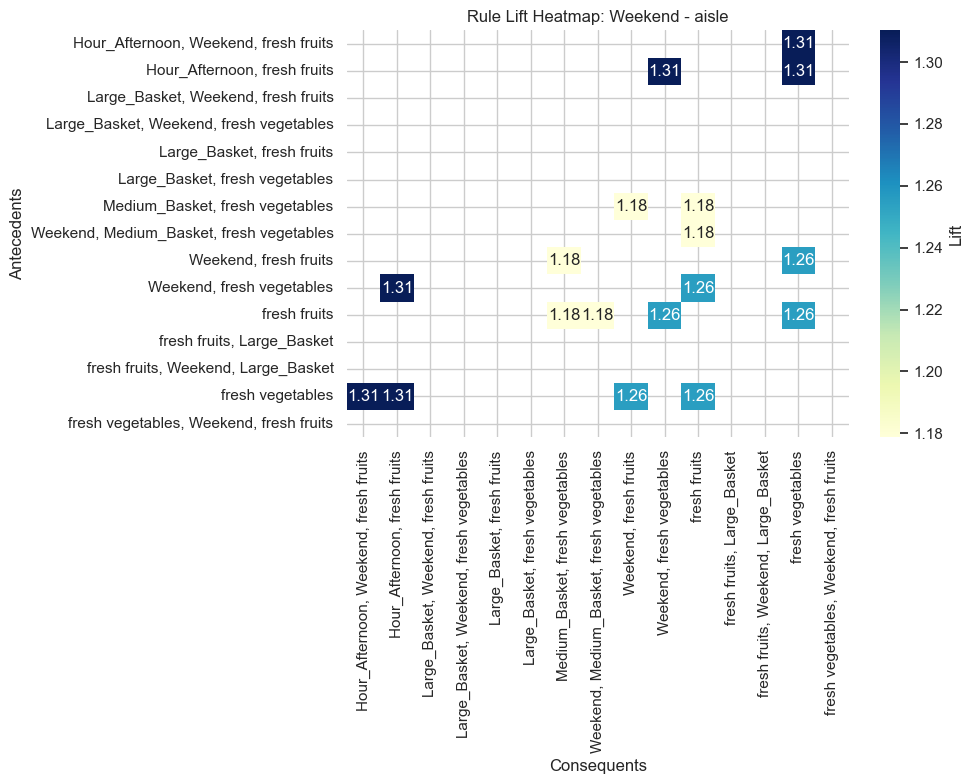

----------------------------------------


### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `7,642`
- **Unique Rules:** `1,424`
- **Robust Rules:** `0`

**Performance:** Apriori took `5.75s` | FP-Growth took `0.59s` *(⚡ FP-Growth is **9.8x** faster)*

----------------------------------------


<br>

---
## DIMENSION: **WEEKDAY**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `3,010`
- **Unique Rules:** `3,010`
- **Robust Rules:** `228`

**Performance:** Apriori took `0.21s` | FP-Growth took `0.16s` *(⚡ FP-Growth is **1.3x** faster)*

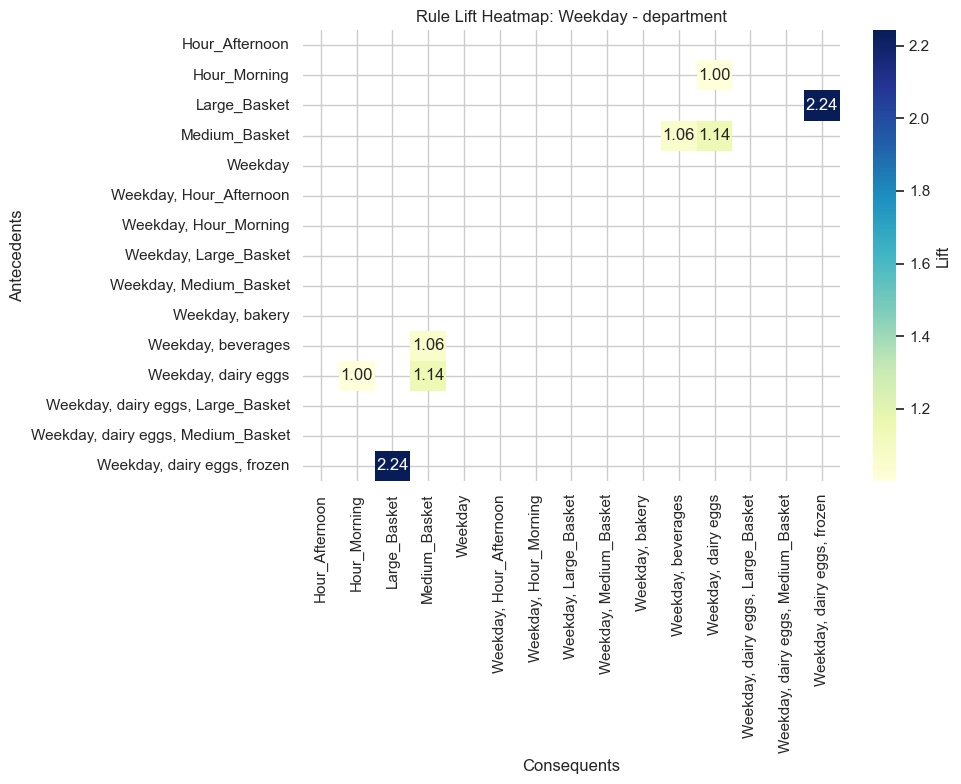

----------------------------------------


### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `33,796`
- **Unique Rules:** `19,608`
- **Robust Rules:** `30`

**Performance:** Apriori took `10.47s` | FP-Growth took `0.39s` *(⚡ FP-Growth is **27.1x** faster)*

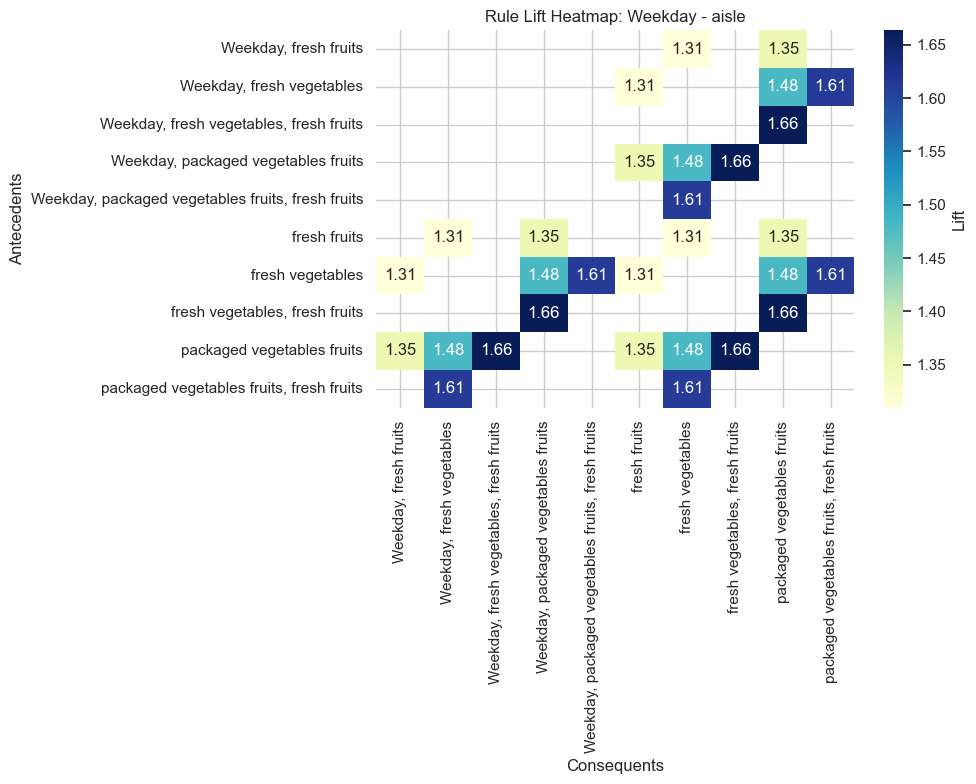

----------------------------------------


### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `5,014`
- **Unique Rules:** `1,044`
- **Robust Rules:** `0`

**Performance:** Apriori took `12.88s` | FP-Growth took `1.49s` *(⚡ FP-Growth is **8.7x** faster)*

----------------------------------------


<br>

---
## DIMENSION: **HOUR_MORNING**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `3,848`
- **Unique Rules:** `3,848`
- **Robust Rules:** `314`

**Performance:** Apriori took `0.11s` | FP-Growth took `0.06s` *(⚡ FP-Growth is **1.7x** faster)*

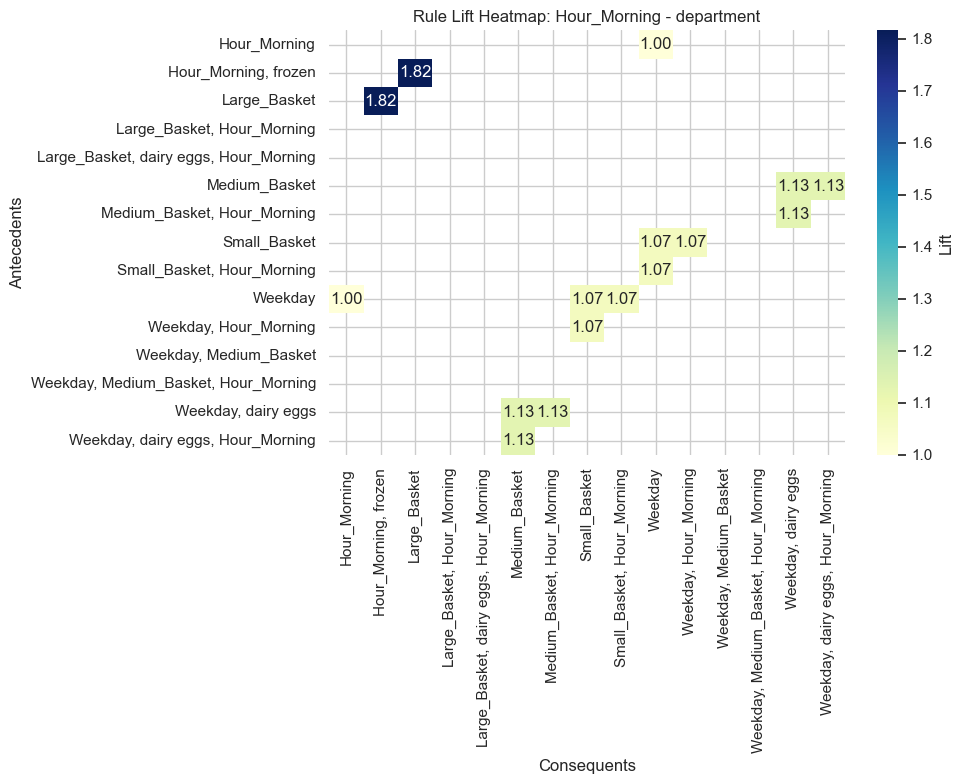

### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `58,952`
- **Unique Rules:** `33,682`
- **Robust Rules:** `54`

**Performance:** Apriori took `5.33s` | FP-Growth took `0.35s` *(⚡ FP-Growth is **15.3x** faster)*

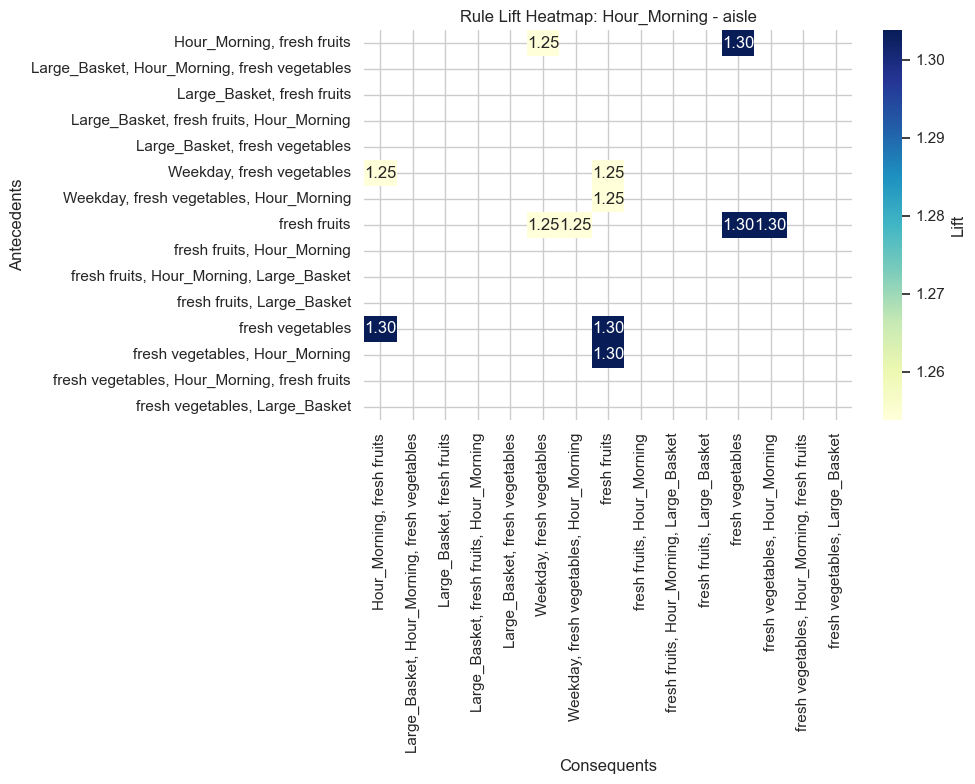

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `7,726`
- **Unique Rules:** `1,676`
- **Robust Rules:** `6`

**Performance:** Apriori took `6.34s` | FP-Growth took `0.51s` *(⚡ FP-Growth is **12.5x** faster)*

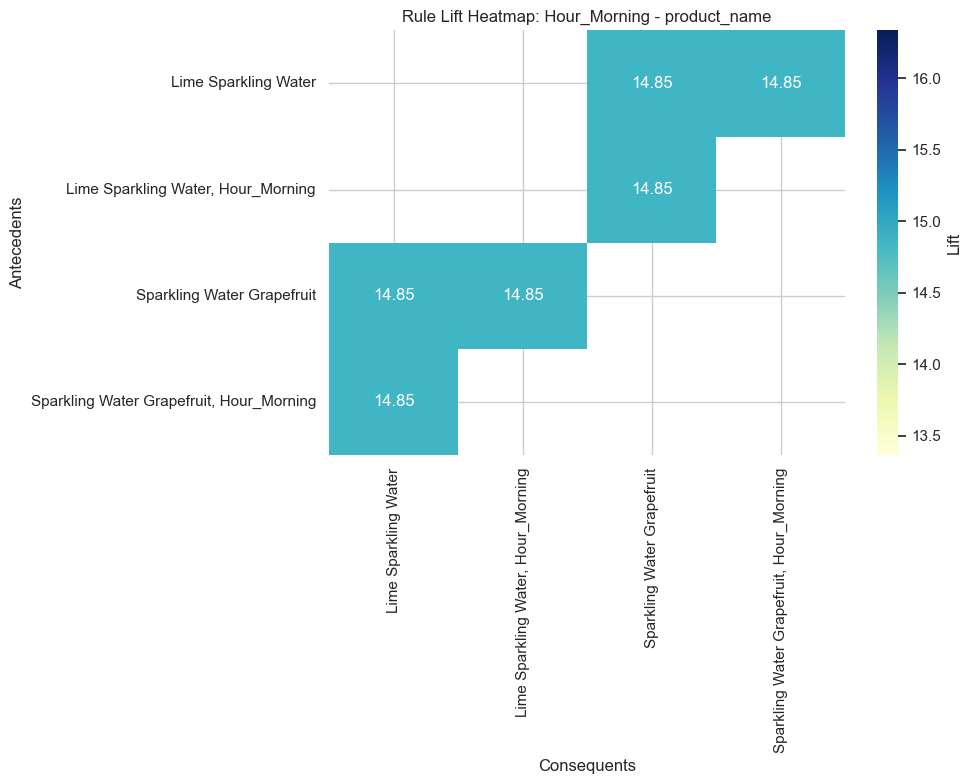

<br>

---
## DIMENSION: **HOUR_AFTERNOON**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `3,776`
- **Unique Rules:** `3,776`
- **Robust Rules:** `262`

**Performance:** Apriori took `0.15s` | FP-Growth took `0.09s` *(⚡ FP-Growth is **1.6x** faster)*

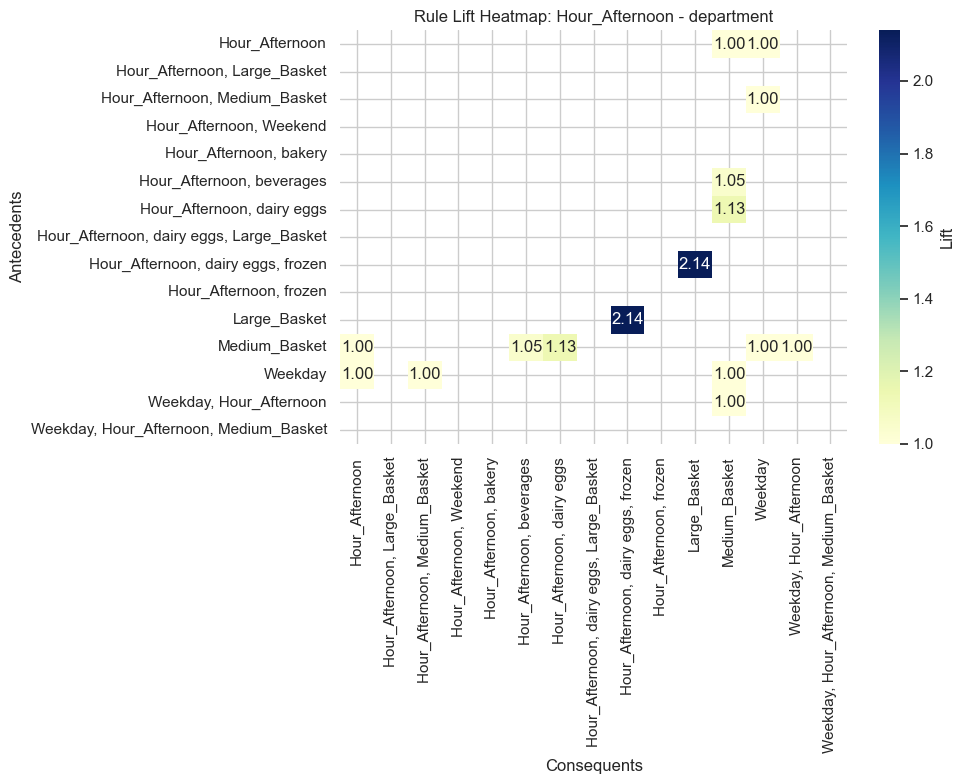

### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `48,586`
- **Unique Rules:** `27,462`
- **Robust Rules:** `54`

**Performance:** Apriori took `7.04s` | FP-Growth took `0.95s` *(⚡ FP-Growth is **7.4x** faster)*

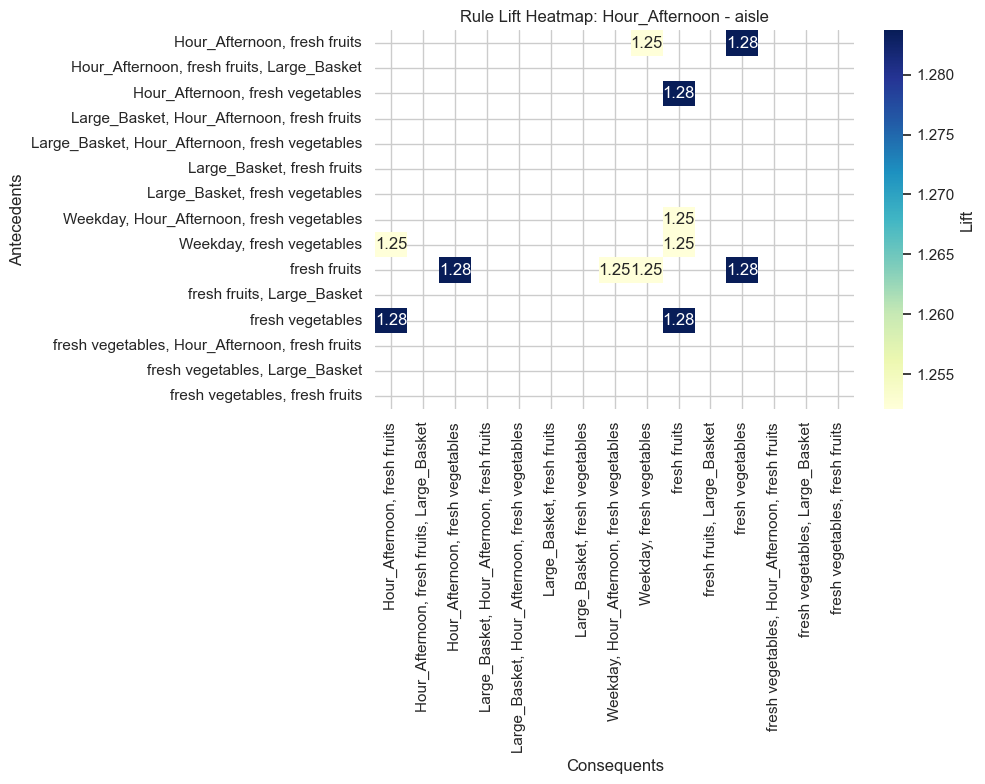

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `6,362`
- **Unique Rules:** `1,154`
- **Robust Rules:** `0`

**Performance:** Apriori took `9.17s` | FP-Growth took `0.72s` *(⚡ FP-Growth is **12.7x** faster)*

<br>

---
## DIMENSION: **HOUR_EVENING**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `4,472`
- **Unique Rules:** `4,472`
- **Robust Rules:** `328`

**Performance:** Apriori took `0.05s` | FP-Growth took `0.04s` *(⚡ FP-Growth is **1.2x** faster)*

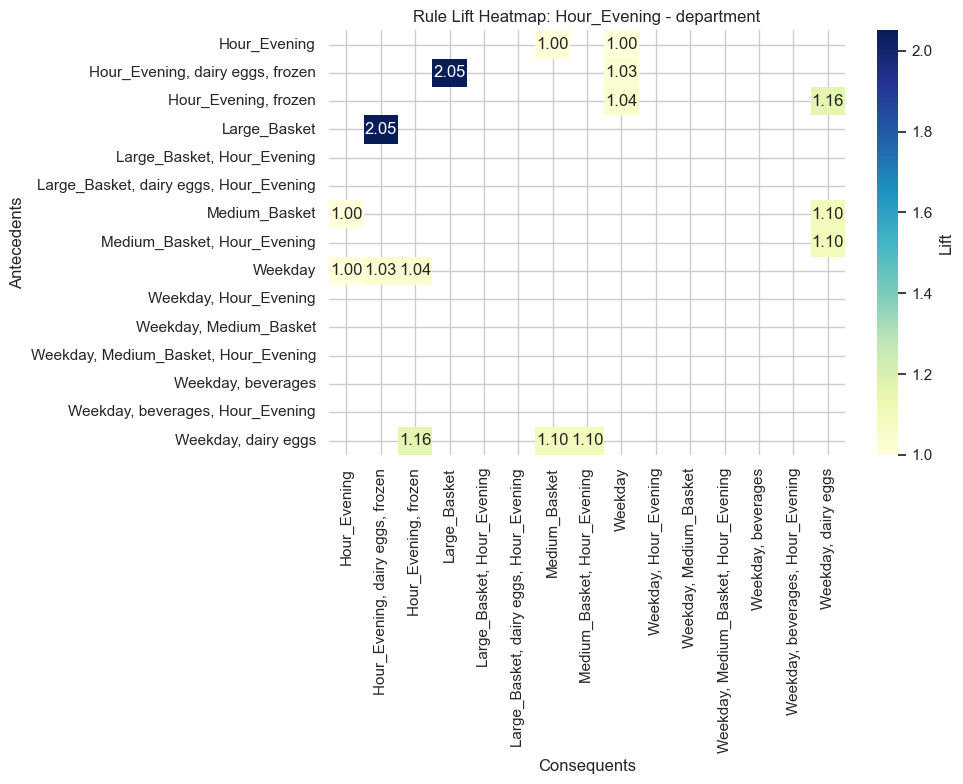

### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `55,976`
- **Unique Rules:** `31,868`
- **Robust Rules:** `60`

**Performance:** Apriori took `2.82s` | FP-Growth took `0.19s` *(⚡ FP-Growth is **14.9x** faster)*

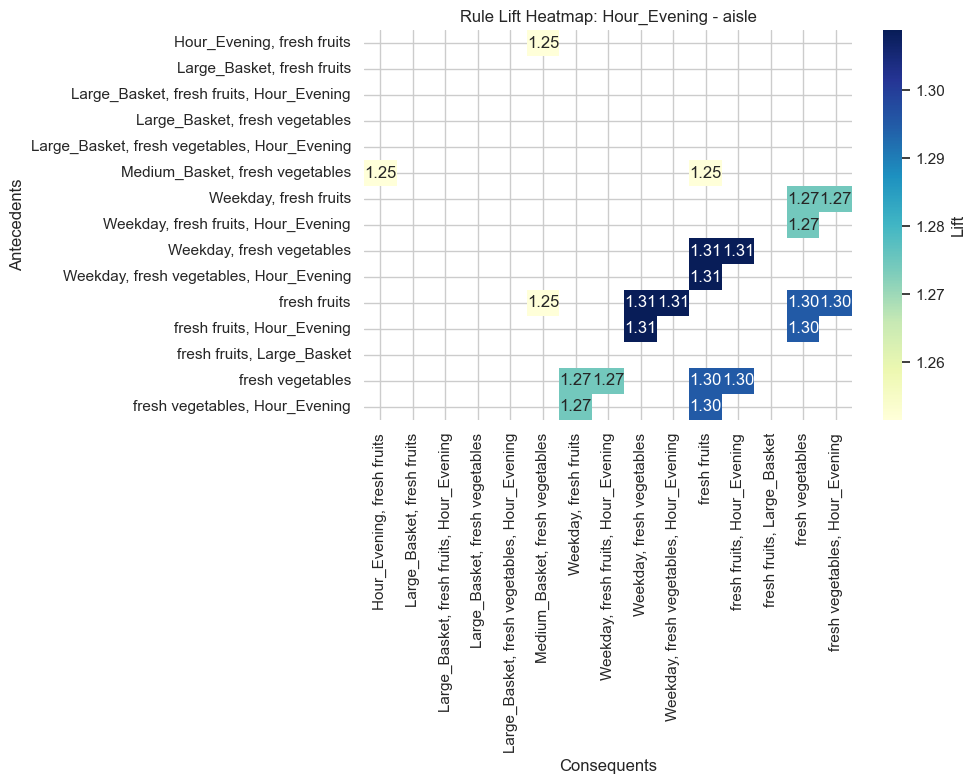

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `7,482`
- **Unique Rules:** `1,496`
- **Robust Rules:** `0`

**Performance:** Apriori took `3.45s` | FP-Growth took `0.28s` *(⚡ FP-Growth is **12.4x** faster)*

<br>

---
## DIMENSION: **HOUR_NIGHT**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.1)*

- **Rules Found:** `2,920`
- **Unique Rules:** `2,920`
- **Robust Rules:** `232`

**Performance:** Apriori took `0.01s` | FP-Growth took `0.01s` *(⚡ FP-Growth is **1.1x** faster)*

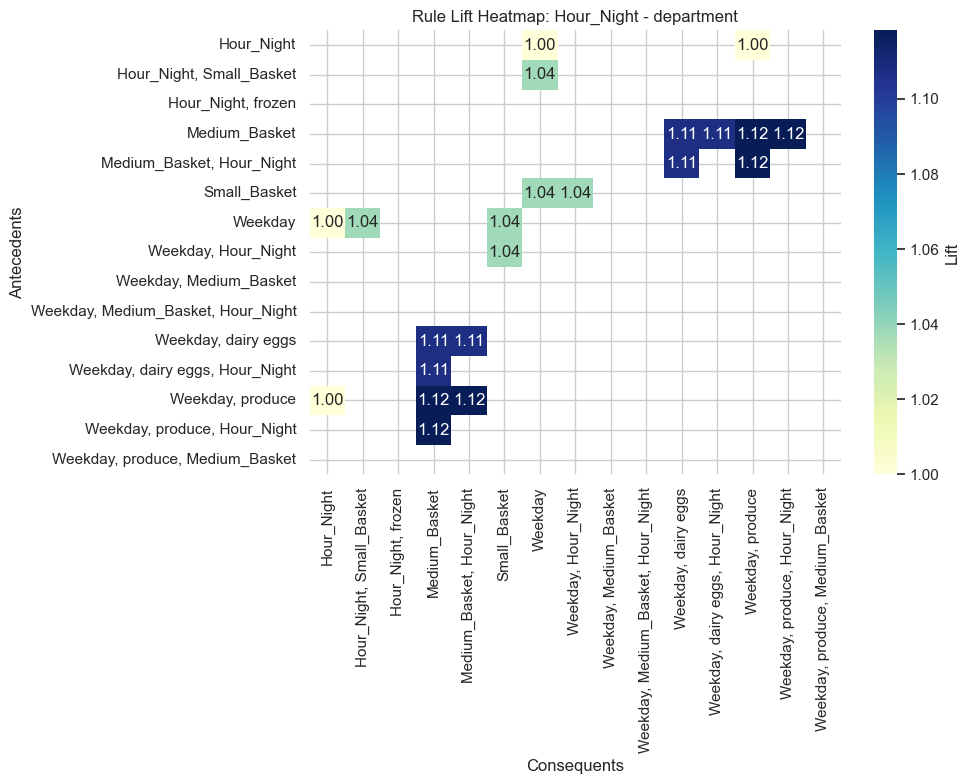

### LEVEL: **AISLE** *(Min Support: 0.02)*

- **Rules Found:** `45,894`
- **Unique Rules:** `28,712`
- **Robust Rules:** `42`

**Performance:** Apriori took `0.33s` | FP-Growth took `0.03s` *(⚡ FP-Growth is **9.7x** faster)*

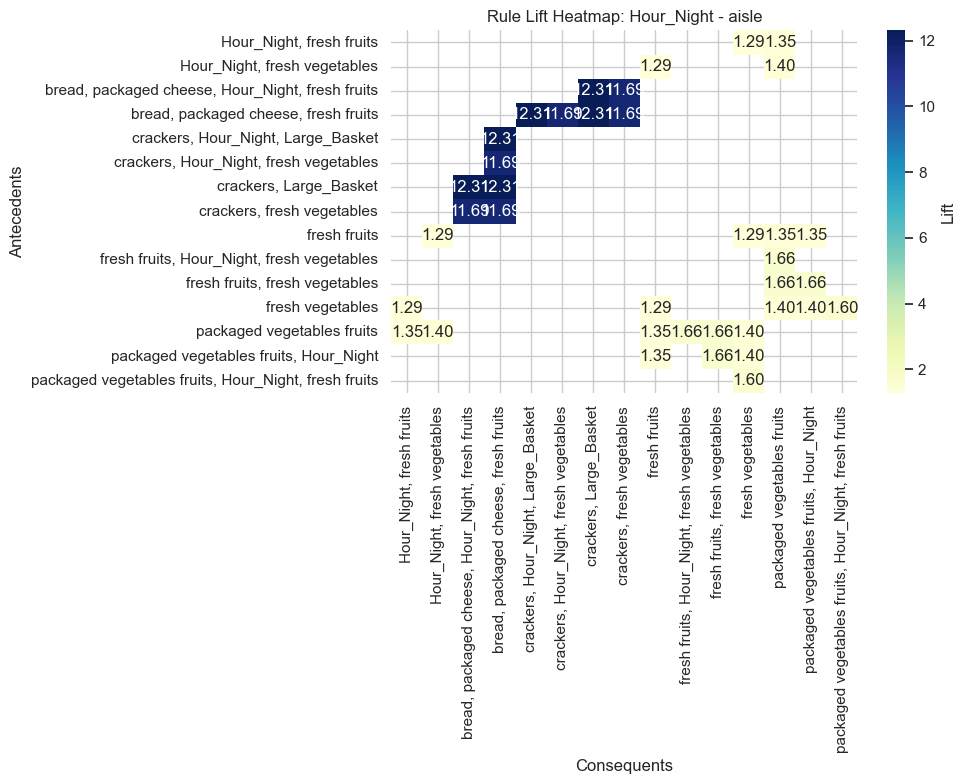

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.005)*

- **Rules Found:** `79,564`
- **Unique Rules:** `45,184`
- **Robust Rules:** `26,058`

**Performance:** Apriori took `3.50s` | FP-Growth took `0.10s` *(⚡ FP-Growth is **34.0x** faster)*

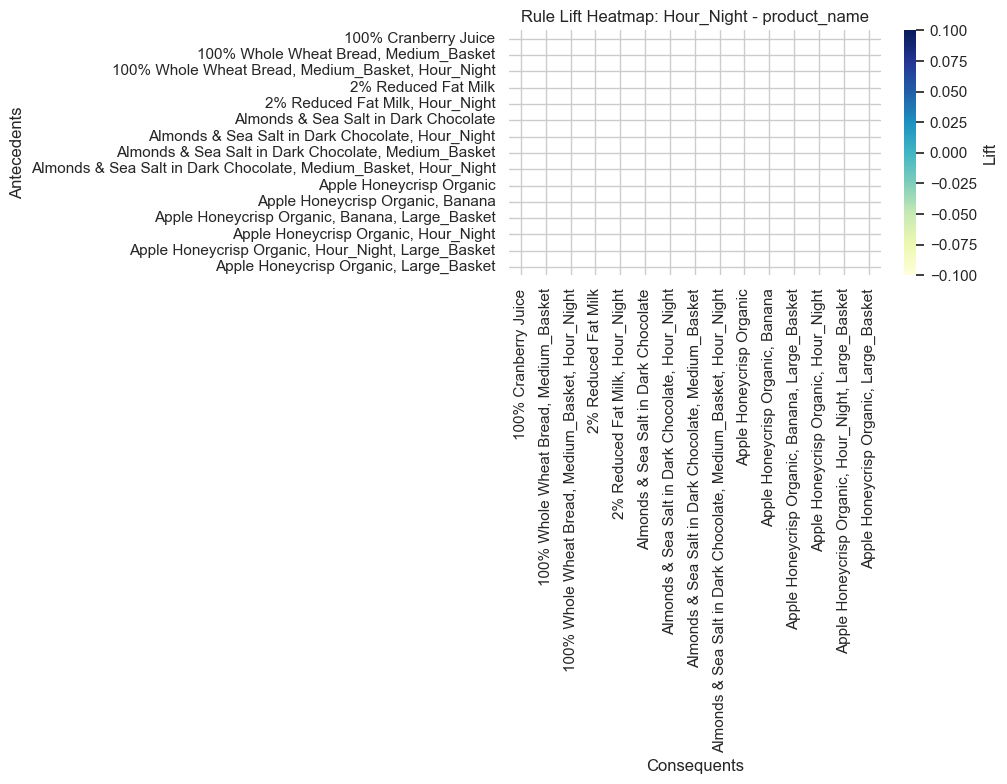

## Algorithm Performance Comparison

In [12]:

df_merged = load_and_prep_data()
results = run_master_analysis(df_merged)

In [13]:
display(Markdown("### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))"))

conflicts_found = False
for (dim, level), df in results.items():
    if not df.empty:
        conflicting_rules = df[(df['lift'] > 2) & (df['kulczynski'] < 0.4)].copy()        
        if not conflicting_rules.empty:
            conflicts_found = True
            display(Markdown(f"**Dimension:** `{dim}` | **Level:** `{level}`"))
            conflicting_rules = conflicting_rules.sort_values('ir', ascending=False)
            cols_to_show = ['ant_str', 'cons_str', 'support', 'confidence', 'lift', 'kulczynski', 'ir']
            display(conflicting_rules[cols_to_show].head(5))

### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))

**Dimension:** `Weekend` | **Level:** `aisle`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
60991,"packaged vegetables fruits, Weekend, cereal, L...","fresh fruits, fresh vegetables",0.02002,0.734043,2.041047,0.394855,0.905892
60969,"fresh fruits, fresh vegetables","packaged vegetables fruits, cereal, Large_Basket",0.02002,0.055668,2.041047,0.394855,0.905892
61010,"packaged vegetables fruits, cereal, Large_Basket","fresh fruits, Weekend, fresh vegetables",0.02002,0.734043,2.041047,0.394855,0.905892
61030,"fresh fruits, fresh vegetables","packaged vegetables fruits, Weekend, cereal, L...",0.02002,0.055668,2.041047,0.394855,0.905892
60960,"packaged vegetables fruits, cereal, Large_Basket","fresh fruits, fresh vegetables",0.02002,0.734043,2.041047,0.394855,0.905892


**Dimension:** `Weekend` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
3509,"Organic Cilantro, Hour_Morning","Weekend, Large_Basket",0.005658,0.549296,2.554855,0.287806,0.931968
3510,Large_Basket,"Weekend, Organic Cilantro, Hour_Morning",0.005658,0.026316,2.554855,0.287806,0.931968
3497,Large_Basket,"Organic Cilantro, Hour_Morning",0.005658,0.026316,2.554855,0.287806,0.931968
3496,"Organic Cilantro, Hour_Morning",Large_Basket,0.005658,0.549296,2.554855,0.287806,0.931968
3504,"Weekend, Large_Basket","Organic Cilantro, Hour_Morning",0.005658,0.026316,2.554855,0.287806,0.931968


...

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
5212,"Weekday, Organic Black Beans","Hour_Evening, Large_Basket",0.005396,0.612903,3.382496,0.321342,0.933846
5209,"Weekday, Organic Black Beans, Hour_Evening",Large_Basket,0.005396,0.612903,3.382496,0.321342,0.933846
5202,"Weekday, Organic Black Beans",Large_Basket,0.005396,0.612903,3.382496,0.321342,0.933846
5207,Large_Basket,"Weekday, Organic Black Beans",0.005396,0.029781,3.382496,0.321342,0.933846
5220,Large_Basket,"Weekday, Organic Black Beans, Hour_Evening",0.005396,0.029781,3.382496,0.321342,0.933846


**Dimension:** `Hour_Night` | **Level:** `aisle`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
29161,"bread, crackers, fresh vegetables","Weekday, fresh fruits",0.021053,0.727273,2.047138,0.393266,0.898551
25636,"Weekday, fresh fruits","bread, yogurt, Large_Basket",0.021053,0.059259,2.047138,0.393266,0.898551
30604,"crackers, packaged vegetables fruits, Large_Ba...","Weekday, Hour_Night, fresh fruits",0.021053,0.727273,2.047138,0.393266,0.898551
29217,"bread, crackers, fresh vegetables","Weekday, Hour_Night, fresh fruits",0.021053,0.727273,2.047138,0.393266,0.898551
25915,"Weekday, Hour_Night, fresh fruits","bread, Large_Basket, yogurt, fresh vegetables",0.021053,0.059259,2.047138,0.393266,0.898551


**Dimension:** `Hour_Night` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
41610,"Weekday, Small_Basket","Cage Free Grade A Large Brown Eggs, Hour_Night",0.005263,0.019231,2.435897,0.342949,0.961905
41606,"Weekday, Hour_Night, Small_Basket",Cage Free Grade A Large Brown Eggs,0.005263,0.019231,2.435897,0.342949,0.961905
41599,"Weekday, Small_Basket",Cage Free Grade A Large Brown Eggs,0.005263,0.019231,2.435897,0.342949,0.961905
41602,Cage Free Grade A Large Brown Eggs,"Weekday, Small_Basket",0.005263,0.666667,2.435897,0.342949,0.961905
41615,Cage Free Grade A Large Brown Eggs,"Weekday, Hour_Night, Small_Basket",0.005263,0.666667,2.435897,0.342949,0.961905


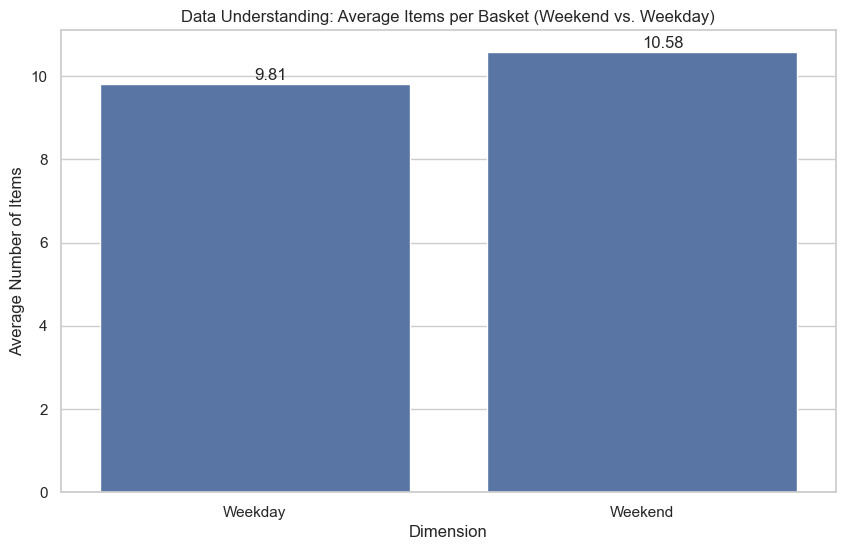

Weekend baskets are larger than Weekday baskets on average


##Multi-Level & Multi-Dimensional Mining Summary

,Dimension,Level,Total_Found,Robust_Count,Avg_Lift,Avg_Kulc
0,Weekend,Department,3714,272,1.2357,0.4857
1,Weekend,Aisle,40058,60,2.0520,0.3296
2,Weekend,Product_name,1424,0,1.7796,0.1921
3,Weekday,Department,3010,228,1.2194,0.4771
4,Weekday,Aisle,19608,30,1.9986,0.3201
5,Weekday,Product_name,1044,0,1.7306,0.1954


The 'Total_Found' column shows rules after hierarchical redundancy filtering

The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds

No strictly 'robust' rules found for Weekend -> product_name. Falling back to top Lift.
No strictly 'robust' rules found for Weekday -> product_name. Falling back to top Lift.


'Top 5 Robust Product Rules (Weekend vs. Weekday)'

,Dimension,ant_str,cons_str,lift,kulczynski,cosine
0,Weekend,"Large Lemon, Large_Basket","Limes, Weekend",5.085563,0.171535,0.165221
1,Weekend,"Limes, Weekend","Large Lemon, Large_Basket",5.085563,0.171535,0.165221
2,Weekend,Limes,"Large Lemon, Large_Basket",5.085563,0.171535,0.165221
3,Weekend,"Large Lemon, Weekend, Large_Basket",Limes,5.085563,0.171535,0.165221
4,Weekend,"Large Lemon, Large_Basket",Limes,5.085563,0.171535,0.165221
5,Weekday,"Large Lemon, Large_Basket",Limes,6.728712,0.207465,0.190661
6,Weekday,"Weekday, Large Lemon, Large_Basket",Limes,6.728712,0.207465,0.190661
7,Weekday,"Large Lemon, Large_Basket","Weekday, Limes",6.728712,0.207465,0.190661
8,Weekday,"Weekday, Limes","Large Lemon, Large_Basket",6.728712,0.207465,0.190661
9,Weekday,Limes,"Weekday, Large Lemon, Large_Basket",6.728712,0.207465,0.190661


In [14]:
plt.figure(figsize=(10, 6))
basket_stats = df_merged.groupby(['day_type', 'order_id']).size().reset_index(name='items')
avg_items = basket_stats.groupby('day_type')['items'].mean()

sns.barplot(x=avg_items.index, y=avg_items.values)
plt.title('Data Understanding: Average Items per Basket (Weekend vs. Weekday)')
plt.ylabel('Average Number of Items')
plt.xlabel('Dimension')
for i, v in enumerate(avg_items.values): plt.text(i, v + 0.1, f"{v:.2f}")
plt.show()
print(f"{avg_items.idxmax()} baskets are larger than {avg_items.idxmin()} baskets on average")

summary_data = []

for dim in ['Weekend', 'Weekday']:
    for level in ['department', 'aisle', 'product_name']:
        key = (dim, level)
        if key in results:
            df = results[key]
            summary_data.append({
                'Dimension': dim,
                'Level': level.capitalize(),
                'Total_Found': len(df),
                'Robust_Count': df['is_robust'].sum(),
                'Avg_Lift': round(df['lift'].mean(), 4) if not df.empty else 0,
                'Avg_Kulc': round(df['kulczynski'].mean(), 4) if not df.empty else 0
            })

summary_df = pd.DataFrame(summary_data)
display(Markdown("##Multi-Level & Multi-Dimensional Mining Summary"))
display(summary_df)
display(Markdown("The 'Total_Found' column shows rules after hierarchical redundancy filtering"))
display(Markdown("The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds"))

def get_top_robust(dim, level, n=5):
    key = (dim, level)
    if key in results:
        df = results[key]
        if df.empty: return pd.DataFrame()
        robust_df = df[df['is_robust']].sort_values('lift', ascending=False).head(n).copy()
        if robust_df.empty:
            print(f"No strictly 'robust' rules found for {dim} -> {level}. Falling back to top Lift.")
            robust_df = df.sort_values('lift', ascending=False).head(n).copy()
        robust_df['Dimension'] = dim
        return robust_df[['Dimension', 'ant_str', 'cons_str', 'lift', 'kulczynski', 'cosine']]
    return pd.DataFrame()

weekend_top = get_top_robust('Weekend', 'product_name')
weekday_top = get_top_robust('Weekday', 'product_name')
comparison_table = pd.concat([weekend_top, weekday_top], ignore_index=True)

display("Top 5 Robust Product Rules (Weekend vs. Weekday)")
display(comparison_table)